<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta atividade, você irá trabalhar com o dataset Fashion MNIST utilizando modelos de classificação do sklearn.

O foco NÃO é apenas obter bons resultados, mas garantir que o experimento seja:
- correto
- reprodutível
- bem estruturado
- criticamente analisado

# Dicas importantes

## Sobre o dataset (Fashion MNIST)

- Utilize `fetch_openml` do sklearn para carregar os dados
- Use: `as_frame=False`
- Use: `mnist_784`
- Converta os rótulos para inteiro:
  
  ```python
  y = y.astype(int)
  ```

# Questão 1

Implemente uma função load_data(seed) que:

Carregue o dataset `Fashion MNIST`
Realize a separação em treino e teste
Utilize `train_test_split` com controle de aleatoriedade
Retorne: `X_train`, `X_test`, `y_train`, `y_test`

Depois responda: 
É necessário normalizar os dados para esse tipo de modelo? Justifique.

**Solução**:

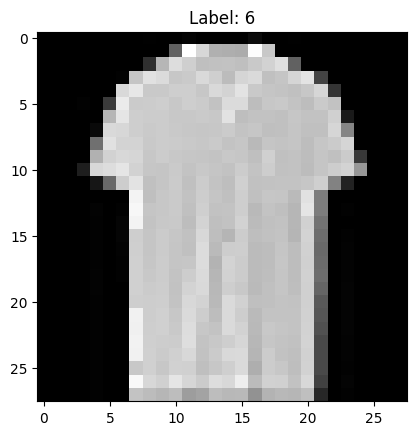

In [5]:
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

def load_data(seed):
    # Carrega o dataset
    (X, y), (_, _) = fashion_mnist.load_data()
    
    # Achata as imagens (28x28 -> 784), se necessário para modelos tradicionais
    X = X.reshape((X.shape[0], -1))
    
    # Divide em treino e teste com controle de aleatoriedade
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=seed, 
        stratify=y  # mantém proporção das classes
    )
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data(seed=42)

plt.imshow(X_train[1].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

# R1 
    Nao é necessario normalizar os dados pois tanto o RandomForest e o AdaBoost são baseados em arvores de decisão dessa maneira ele ira escolher entre um dado ou outro sem ser necessario nenhum calculo, somente verificação. 

# Questão 2

Implemente as funções:

`train_random_forest(X_train, y_train, seed)`
`train_adaboost(X_train, y_train, seed)`

## Requisitos:

Utilizar os modelos do `sklearn`
Garantir reprodutibilidade com `random_state`

**Solução**:

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

def train_random_forest(X_train, y_train, seed):
    model = RandomForestClassifier(
        n_estimators=45,       # número de árvores
        random_state=seed,      # reprodutibilidade
        n_jobs=-1               # usa todos os núcleos
    )
    
    model.fit(X_train, y_train)
    return model




def train_adaboost(X_train, y_train, seed):
    model = AdaBoostClassifier(
        n_estimators=45,       # número de classificadores fracos
        learning_rate=1.0,      # taxa de aprendizado
        random_state=seed       # reprodutibilidade
    )
    
    model.fit(X_train, y_train)
    return model


rf = train_random_forest(X_train, y_train, seed=42)

ada = train_adaboost(X_train, y_train, seed=42)

# Questão 3

Implemente a função:

- `evaluate(model, X_test, y_test)`

Ela deve:
- Realizar predições
- Retornar a acurácia do modelo

**Solução**:

In [7]:
from sklearn.metrics import accuracy_score

def evaluate(model, X_test, y_test):
    # Faz as predições
    y_pred = model.predict(X_test)
    
    # Calcula a acurácia
    acc = accuracy_score(y_test, y_pred)
    
    return acc


acc_rf = evaluate(rf, X_test, y_test)
acc_ada = evaluate(ada, X_test, y_test)

print("Random Forest:", acc_rf)
print("AdaBoost:", acc_ada)

Random Forest: 0.88025
AdaBoost: 0.48275


**Adicione seu texto de solução aqui**.

A RandomForest foi bem mais eficiente além de ter sido consideravelmente mais rápida tambem teve um acuracia maior do que o AdaBoost

# Questão 4

Implemente a função:

- `run_pipeline(model_type="rf", seed=42)`

Ela deve:
- Carregar os dados
- Treinar o modelo escolhido (`rf` ou `ab`)
- Avaliar o modelo
- Retornar a acurácia

**Solução**:

In [8]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

def run_pipeline(model_type="rf", seed=42):
    X_train, X_test, y_train, y_test = load_data(seed)
    
    # 👉 Caso Random Forest (com loop)
    if model_type == "rf":
        depths = [2, 5, 10, 15, 20, None]
        
        for depth in depths:
            model = RandomForestClassifier(
                n_estimators=10,
                max_depth=depth,
                random_state=seed,
                n_jobs=-1
            )
            
            model.fit(X_train, y_train)
            
            train_acc = accuracy_score(y_train, model.predict(X_train))
            test_acc = accuracy_score(y_test, model.predict(X_test))
            
            print(f"Depth: {depth}")
            print(f"  Train: {train_acc:.4f}")
            print(f"  Test : {test_acc:.4f}")
            print("-" * 30)
    
    # 👉 Caso AdaBoost (sem loop)
    elif model_type == "ada":
        model = AdaBoostClassifier(
            n_estimators=10,
            random_state=seed
        )
        
        model.fit(X_train, y_train)
        
        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))
        
        print("AdaBoost (única execução)")
        print(f"  Train: {train_acc:.4f}")
        print(f"  Test : {test_acc:.4f}")
    
    else:
        raise ValueError("model_type deve ser 'rf' ou 'ada'")


#----------------MAIN--------------------------------------------------------

run_pipeline("rf", seed=42)
run_pipeline("ada", seed=42)

Depth: 2
  Train: 0.5973
  Test : 0.6018
------------------------------
Depth: 5
  Train: 0.7733
  Test : 0.7732
------------------------------
Depth: 10
  Train: 0.8739
  Test : 0.8479
------------------------------
Depth: 15
  Train: 0.9604
  Test : 0.8639
------------------------------
Depth: 20
  Train: 0.9879
  Test : 0.8623
------------------------------
Depth: None
  Train: 0.9955
  Test : 0.8596
------------------------------
AdaBoost (única execução)
  Train: 0.3816
  Test : 0.3833


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

**1**
Na profundidade 10 já é possivel visualizar um leve overfitting porém pequeno, mas deste valor para cima o overgitting aumenta cada vez mais~.
**2**
A arvore consegeu 100% no treino quando a mex_depth é igual NONE porque a arvore vai dividir todos os dados, acertando todos, porém ela tambem não ira aprender pois, quando for para os testes ela terá decorado e não conseguira validar dados novos.

# Questão 5

Execute o pipeline para ambos os modelos:

- Random Forest
- AdaBoost

## Apresente:
- Acurácia, Precisão, Recall e F1-Score de cada modelo

## Responda:
- Qual modelo apresentou melhor desempenho inicial?

**Solução**:

In [9]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

def run_pipeline(model_type="rf", seed=42):
    X_train, X_test, y_train, y_test = load_data(seed)
    
    # 👉 Caso Random Forest (com loop)
    if model_type == "rf":
        depths = [2, 5, 10, 15, 20, None]
        
        for depth in depths:
            model = RandomForestClassifier(
                n_estimators=10,
                max_depth=depth,
                random_state=seed,
                n_jobs=-1
            )
            
            model.fit(X_train, y_train)
            
            train_acc = accuracy_score(y_train, model.predict(X_train))
            test_acc = accuracy_score(y_test, model.predict(X_test))
            
            print(f"Depth: {depth}")
            print(f"  Train: {train_acc:.4f}")
            print(f"  Test : {test_acc:.4f}")
            print("-" * 30)
    
    # 👉 Caso AdaBoost (sem loop)
    elif model_type == "ada":
        model = AdaBoostClassifier(
            n_estimators=10,
            random_state=seed
        )
        
        model.fit(X_train, y_train)
        
        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))
        
        print("AdaBoost (única execução)")
        print(f"  Train: {train_acc:.4f}")
        print(f"  Test : {test_acc:.4f}")
    
    else:
        raise ValueError("model_type deve ser 'rf' ou 'ada'")


#----------------MAIN--------------------------------------------------------

run_pipeline("rf", seed=42)
run_pipeline("ada", seed=42)

Depth: 2
  Train: 0.5973
  Test : 0.6018
------------------------------
Depth: 5
  Train: 0.7733
  Test : 0.7732
------------------------------
Depth: 10
  Train: 0.8739
  Test : 0.8479
------------------------------
Depth: 15
  Train: 0.9604
  Test : 0.8639
------------------------------
Depth: 20
  Train: 0.9879
  Test : 0.8623
------------------------------
Depth: None
  Train: 0.9955
  Test : 0.8596
------------------------------
AdaBoost (única execução)
  Train: 0.3816
  Test : 0.3833


**R**
A RandomForest possui um desempenho muito melhor do que o AdaBoost além de ser mais rápida esta apresentando uma acuracia maior em relação ao AdaBoost, talvez em longo prazo AdaBoost seja melhor porem na maioria das resoluções a RandomForest sai ganhando.

# Questão 6

Execute o pipeline utilizando diferentes seeds (ex: 42 e 7).

## Analise:
- Os resultados mudaram?

## Responda:
- O experimento é reprodutível? Justifique.

**Solução**:

In [14]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

def run_pipeline(model_type="rf", seed = 42):
    X_train, X_test, y_train, y_test = load_data(seed)
    
    # 👉 Caso Random Forest (com loop)
    if model_type == "rf":
        depths = [2, 5, 10, 15, 20, None]
        
        for depth in depths:
            model = RandomForestClassifier(
                n_estimators=10,
                max_depth=depth,
                random_state=seed,
                n_jobs=-1
            )
            
            model.fit(X_train, y_train)
            
            train_acc = accuracy_score(y_train, model.predict(X_train))
            test_acc = accuracy_score(y_test, model.predict(X_test))
            
            print(f"Depth: {depth}")
            print(f"  Train: {train_acc:.4f}")
            print(f"  Test : {test_acc:.4f}")
            print("-" * 30)
    
    # 👉 Caso AdaBoost (sem loop)
    elif model_type == "ada":
        model = AdaBoostClassifier(
            n_estimators=10,
            random_state=seed
        )
        
        model.fit(X_train, y_train)
        
        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))
        
        print("AdaBoost (única execução)")
        print(f"  Train: {train_acc:.4f}")
        print(f"  Test : {test_acc:.4f}")
    
    else:
        raise ValueError("model_type deve ser 'rf' ou 'ada'")


#----------------MAIN--------------------------------------------------------
print("Seed---47----------------------------------------------")
run_pipeline("rf", seed = 42)
print("Seed---7-----------------------------------------------")
run_pipeline("rf", seed = 7)

print("Seed---47----------------------------------------------")
run_pipeline("ada", seed = 42)
print("Seed---7----------------------------------------------")
run_pipeline("ada", seed = 7)

Seed---47----------------------------------------------
Depth: 2
  Train: 0.5973
  Test : 0.6018
------------------------------
Depth: 5
  Train: 0.7733
  Test : 0.7732
------------------------------
Depth: 10
  Train: 0.8739
  Test : 0.8479
------------------------------
Depth: 15
  Train: 0.9604
  Test : 0.8639
------------------------------
Depth: 20
  Train: 0.9879
  Test : 0.8623
------------------------------
Depth: None
  Train: 0.9955
  Test : 0.8596
------------------------------
Seed---7-----------------------------------------------
Depth: 2
  Train: 0.5339
  Test : 0.5345
------------------------------
Depth: 5
  Train: 0.7732
  Test : 0.7626
------------------------------
Depth: 10
  Train: 0.8803
  Test : 0.8410
------------------------------
Depth: 15
  Train: 0.9579
  Test : 0.8589
------------------------------
Depth: 20
  Train: 0.9870
  Test : 0.8564
------------------------------
Depth: None
  Train: 0.9949
  Test : 0.8565
------------------------------
Seed---47---

**Resultados Mudaram:**
 Os resultados mudaram um pouco porem não tiveram uma variação muito grande, ou seja a perca na eficiencia foi muito baixa.

**O Experimento é Reprodutivel:**
 Sim, ele é reprodutivel porque os dados forma todos aleatorizados, isso garante a aleatoriedade controlada.

# Questão 7

Para pelo menos um dos modelos:

- Compare a acurácia em treino e teste

## Responda:
- Existe overfitting?
- Qual modelo tende a sofrer mais com isso?

In [11]:
# TODO: implemente load_data

Existe Overfitting somente na RandomForest, porque sua profundidade é variavel já no caso do ADABoost a alteração é pequena devida a sempre possuir profundidade baixa.

# Questão 8

Varie pelo menos um hiperparâmetro em cada modelo:

- Random Forest: `n_estimators`
- AdaBoost: `n_estimators`

## Analise:
- O desempenho muda significativamente?

## Responda:
- Qual modelo é mais sensível a mudanças?

In [21]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

def run_pipeline(model_type="rf", seed=42):
    X_train, X_test, y_train, y_test = load_data(seed)
    
    estimators = [2, 5, 10, 15, 20]
    
    # 👉 Random Forest
    if model_type == "rf":
        print("Random Forest")
        print("-" * 30)
        
        for est in estimators:
            model = RandomForestClassifier(
                n_estimators=est,
                max_depth=10,
                random_state=seed,
                n_jobs=-1
            )
            
            model.fit(X_train, y_train)
            
            train_acc = accuracy_score(y_train, model.predict(X_train))
            test_acc = accuracy_score(y_test, model.predict(X_test))
            
            print(f"Estimators: {est}")
            print(f"  Train: {train_acc:.4f}")
            print(f"  Test : {test_acc:.4f}")
            print("-" * 30)
    
    # 👉 AdaBoost (AGORA variando também)
    elif model_type == "ada":
        print("AdaBoost")
        print("-" * 30)
        
        for est in estimators:
            model = AdaBoostClassifier(
                n_estimators=est,
                random_state=seed
            )
            
            model.fit(X_train, y_train)
            
            train_acc = accuracy_score(y_train, model.predict(X_train))
            test_acc = accuracy_score(y_test, model.predict(X_test))
            
            print(f"Estimators: {est}")
            print(f"  Train: {train_acc:.4f}")
            print(f"  Test : {test_acc:.4f}")
            print("-" * 30)
    
    else:
        raise ValueError("model_type deve ser 'rf' ou 'ada'")


# ---------------- MAIN ----------------

run_pipeline("rf", seed=42)
print("\n")
run_pipeline("ada", seed=42)

Random Forest
------------------------------
Estimators: 2
  Train: 0.8429
  Test : 0.8059
------------------------------
Estimators: 5
  Train: 0.8651
  Test : 0.8383
------------------------------
Estimators: 10
  Train: 0.8739
  Test : 0.8479
------------------------------
Estimators: 15
  Train: 0.8777
  Test : 0.8539
------------------------------
Estimators: 20
  Train: 0.8796
  Test : 0.8523
------------------------------


AdaBoost
------------------------------
Estimators: 2
  Train: 0.1976
  Test : 0.1970
------------------------------
Estimators: 5
  Train: 0.2636
  Test : 0.2617
------------------------------
Estimators: 10
  Train: 0.3816
  Test : 0.3833
------------------------------
Estimators: 15
  Train: 0.3638
  Test : 0.3683
------------------------------
Estimators: 20
  Train: 0.3591
  Test : 0.3632
------------------------------


Os resultados mudam mais significamente no AdaBoost a mundança no RandomForest é quase que insignificante, ou seja o numero de estimators é relevante somente para o AdaBoost.

# Questão 9

Responda (máx. 2 parágrafos por item):

1. A acurácia é suficiente para avaliar os modelos?
2. Como você garante que o resultado não ocorreu por acaso?
3. Cite dois possíveis problemas metodológicos neste experimento.
4. O pipeline implementado é confiável? Justifique.

In [13]:
# TODO: implemente load_data

**1-**
Não é suficiente para avaliar os modelos deve ser tomado em consideração outros fatores, por exemplo o tempo de execução.
**2-**
Isso é garantido devido ao treinamento feito antes dos testes reais. Além disso utilizando a Seed.
**3-**
Uso de apenas uma divisão de treino/teste, não usa Cross-Validation
**4-**
Não usa validação cruzada e tem uma avalição limitada da acuracia, mas tirando isso ela é confiavel pelo uso de Random_State e de uma seed.